In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


c:\Users\mahal\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
bank_df = pd.read_csv("UniversalBank.csv")
bank_df.head()


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
bank_df.info()
bank_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

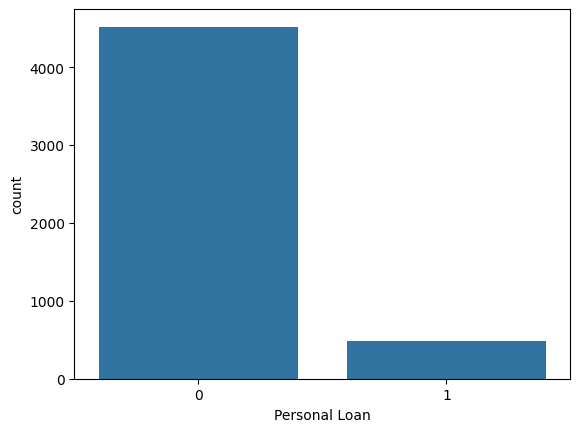

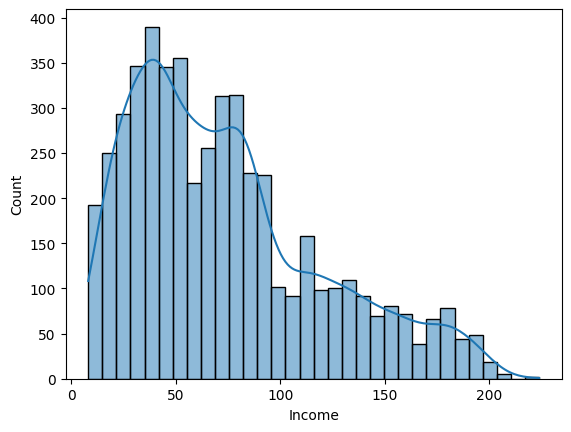

In [4]:
sns.countplot(x="Personal Loan", data=bank_df)
plt.show()

sns.histplot(bank_df["Income"], kde=True)
plt.show()


In [5]:
X = bank_df.drop(columns=["Personal Loan", "ID", "ZIP Code"])
y = bank_df["Personal Loan"]


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1) split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# 2) scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build model (example for binary classification)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 3) train your keras model on SCALED data
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=20,
    batch_size=32
)

# 4) save scaler + model
joblib.dump(scaler, "scaler.pkl")      # ✅ scaler saved
model.save("loan_model.h5")            # ✅ model saved (H5 format)

print("✅ Saved scaler.pkl and loan_model.h5")


Epoch 1/20
141/141 [==============================] - 1s 3ms/step - loss: 0.2345 - accuracy: 0.9233 - val_loss: 0.1269 - val_accuracy: 0.9420
Epoch 2/20
141/141 [==============================] - 0s 1ms/step - loss: 0.1057 - accuracy: 0.9618 - val_loss: 0.0747 - val_accuracy: 0.9660
Epoch 3/20
141/141 [==============================] - 0s 1ms/step - loss: 0.0811 - accuracy: 0.9711 - val_loss: 0.0608 - val_accuracy: 0.9800
Epoch 4/20
141/141 [==============================] - 0s 2ms/step - loss: 0.0714 - accuracy: 0.9744 - val_loss: 0.0486 - val_accuracy: 0.9880
Epoch 5/20
141/141 [==============================] - 0s 2ms/step - loss: 0.0656 - accuracy: 0.9762 - val_loss: 0.0451 - val_accuracy: 0.9860
Epoch 6/20
141/141 [==============================] - 0s 1ms/step - loss: 0.0612 - accuracy: 0.9787 - val_loss: 0.0441 - val_accuracy: 0.9860
Epoch 7/20
141/141 [==============================] - 0s 1ms/step - loss: 0.0591 - accuracy: 0.9800 - val_loss: 0.0418 - val_accuracy: 0.9860
Epoch 

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")
# Save model



model.save("loan_model.h5")




Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 16)                192       
                                                                 
 dense_4 (Dense)             (None, 8)                 136       
                                                                 
 dense_5 (Dense)             (None, 1)                 9         
                                                                 
Total params: 337
Trainable params: 337
Non-trainable params: 0
_________________________________________________________________


In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
113/113 [==============================] - 1s 3ms/step - loss: 0.5291 - accuracy: 0.7894 - val_loss: 0.4061 - val_accuracy: 0.8967
Epoch 2/20
113/113 [==============================] - 0s 2ms/step - loss: 0.3071 - accuracy: 0.9058 - val_loss: 0.2596 - val_accuracy: 0.8967
Epoch 3/20
113/113 [==============================] - 0s 2ms/step - loss: 0.2053 - accuracy: 0.9058 - val_loss: 0.2045 - val_accuracy: 0.8967
Epoch 4/20
113/113 [==============================] - 0s 2ms/step - loss: 0.1667 - accuracy: 0.9144 - val_loss: 0.1763 - val_accuracy: 0.9189
Epoch 5/20
113/113 [==============================] - 0s 2ms/step - loss: 0.1449 - accuracy: 0.9419 - val_loss: 0.1548 - val_accuracy: 0.9333
Epoch 6/20
113/113 [==============================] - 0s 2ms/step - loss: 0.1266 - accuracy: 0.9547 - val_loss: 0.1350 - val_accuracy: 0.9400
Epoch 7/20
113/113 [==============================] - 0s 2ms/step - loss: 0.1118 - accuracy: 0.9603 - val_loss: 0.1209 - val_accuracy: 0.9467
Epoch 

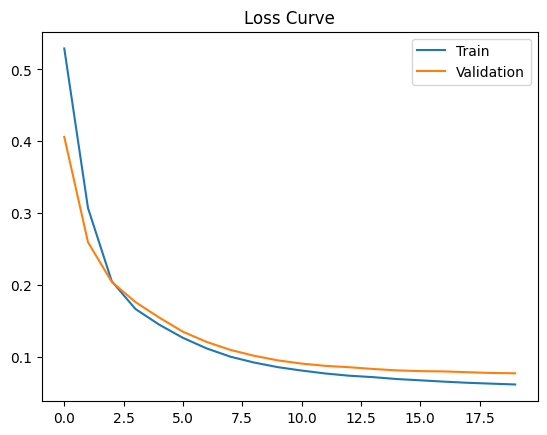

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss Curve")
plt.show()


In [14]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).ravel()


16/16 [==============================] - 0s 682us/step


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.978
Precision: 0.8490566037735849
Recall   : 0.9375
F1 Score : 0.8910891089108911


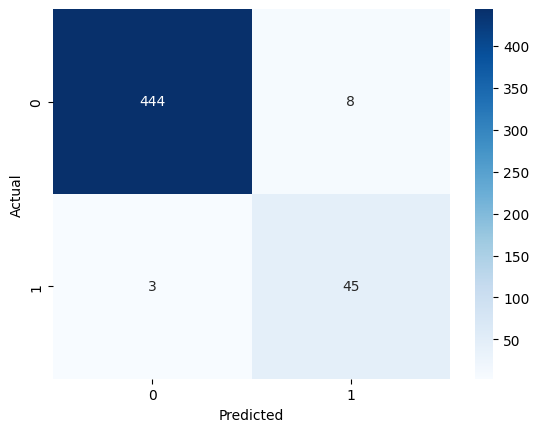

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       452
           1       0.85      0.94      0.89        48

    accuracy                           0.98       500
   macro avg       0.92      0.96      0.94       500
weighted avg       0.98      0.98      0.98       500



In [16]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))


In [17]:
%pip install gradio


Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip cache purge

Files removed: 2453 (7428.3 MB)
Directories removed: 2295
Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install fastapi==0.95.2
%pip install starlette==0.27.0
%pip install uvicorn==0.22.0
%pip install gradio==3.50.2


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 3.0 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.1 MB/s  0:00:00

  Attempting uninstall: pydantic

    Found existing installation: pydantic 2.12.5

    Uninstalling pydantic-2.12.5:

      Successfully uninstalled pydantic-2.12.5

   ---------------------------------------- 0/3 [pydantic]
   ---------------------------------------- 0/3 [pydantic]
  Attempting uninstall: starlette
   ---------------------------------------- 0/3 [pydantic]
    Found existing installation: starlette 0.52.1
   ---------------------------------------- 0/3 [pydantic]
    Uninstalling starlette-0.52.1:
   ---------------------------------------- 0/3 [pydantic]
      Successfully uninstalled starlette-0.52.1
   ----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasa 3.6.21 requires tensorflow-intel==2.12.0; sys_platform == "win32", which is not installed.
google-genai 1.63.0 requires pydantic<3.0.0,>=2.9.0, but you have pydantic 1.10.26 which is incompatible.
google-genai 1.63.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 10.4 which is incompatible.
gradio 6.5.1 requires fastapi<1.0,>=0.115.2, but you have fastapi 0.95.2 which is incompatible.
gradio 6.5.1 requires pydantic<=3.0,>=2.0, but you have pydantic 1.10.26 which is incompatible.
gradio 6.5.1 requires starlette<1.0,>=0.40.0, but you have starlette 0.27.0 which is incompatible.
rasa 3.6.21 requires matplotlib<3.6,>=3.1, but you have matplotlib 3.10.8 which is incompatible.
rasa 3.6.21 requires numpy<1.25.0,>=1.19.2; python_version >= "3.8" and python_version < "3.11", but you have numpy 1.26.4 whi

Note: you may need to restart the kernel to use updated packages.
  Attempting uninstall: uvicorn
    Found existing installation: uvicorn 0.40.0
    Uninstalling uvicorn-0.40.0:
      Successfully uninstalled uvicorn-0.40.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.5.1 requires fastapi<1.0,>=0.115.2, but you have fastapi 0.95.2 which is incompatible.
gradio 6.5.1 requires pydantic<=3.0,>=2.0, but you have pydantic 1.10.26 which is incompatible.
gradio 6.5.1 requires starlette<1.0,>=0.40.0, but you have starlette 0.27.0 which is incompatible.


   ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
    --------------------------------------- 0.3/20.3 MB ? eta -:--:--
    --------------------------------------- 0.3/20.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/20.3 MB 493.7 kB/s eta 0:00:41
   - -------------------------------------- 0.5/20.3 MB 493.7 kB/s eta 0:00:41
   - -------------------------------------- 0.5/20.3 MB 493.7 kB/s eta 0:00:41
   - -------------------------------------- 0.8/20.3 MB 500.8 kB/s eta 0:00:39
   - -------------------------------------- 0.8/20.3 MB 500.8 kB/s eta 0:00:39
   -- ------------------------------------- 1.0/20.3 MB 553.0 kB/s eta 0:00:35
   -- ------------------------------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasa 3.6.21 requires tensorflow-intel==2.12.0; sys_platform == "win32", which is not installed.
flask-sqlalchemy 3.1.1 requires sqlalchemy>=2.0.16, but you have sqlalchemy 1.4.54 which is incompatible.
jupyterlab-server 2.28.0 requires jsonschema>=4.18.0, but you have jsonschema 4.17.3 which is incompatible.
rasa 3.6.21 requires matplotlib<3.6,>=3.1, but you have matplotlib 3.10.8 which is incompatible.
rasa 3.6.21 requires numpy<1.25.0,>=1.19.2; python_version >= "3.8" and python_version < "3.11", but you have numpy 1.26.4 which is incompatible.
rasa 3.6.21 requires packaging<21.0,>=20.0, but you have packaging 26.0 which is incompatible.
rasa 3.6.21 requires prompt-toolkit<3.0.29,>=3.0, but you have prompt-toolkit 3.0.43 which is incompatible.
rasa 3.6.21 requires protobuf<4.

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
import joblib

# Load trained model and scaler
model = tf.keras.models.load_model("loan_model.h5")
scaler = joblib.load("scaler.pkl")

def predict_loan(
    age, exp, income, family, ccavg, education,
    mortgage, securities, cd, online, creditcard
):
    # Convert input to numpy array
    data = np.array([[ 
        age, exp, income, family, ccavg, education,
        mortgage, securities, cd, online, creditcard
    ]], dtype=float)

    # Scale input
    data = scaler.transform(data)

    # Predict probability
    prob = model.predict(data)[0][0]

    # Return result
    return "✅ Loan Approved" if prob > 0.5 else "❌ Loan Not Approved"


interface = gr.Interface(
    fn=predict_loan,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Experience"),
        gr.Number(label="Income"),
        gr.Number(label="Family"),
        gr.Number(label="CCAvg"),
        gr.Dropdown(
            choices=[1, 2, 3],
            label="Education (1=Undergrad, 2=Graduate, 3=Advanced)"
        ),
        gr.Number(label="Mortgage"),
        gr.Dropdown(choices=[0, 1], label="Securities Account"),
        gr.Dropdown(choices=[0, 1], label="CD Account"),
        gr.Dropdown(choices=[0, 1], label="Online Banking"),
        gr.Dropdown(choices=[0, 1], label="Credit Card")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🏦 Universal Bank Loan Prediction",
    description="ANN-based loan approval prediction using Gradio"
)

interface.launch()


Running on local URL:  http://127.0.0.1:7860
IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------

To create a public link, set `share=True` in `launch()`.


1/1 [==============================] - 0s 118ms/step


c:\Users\mahal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
